In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create screenshots folder if it doesn't exist
os.makedirs("screenshots", exist_ok=True)

# Load datasets
crop = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/Crop_recommendation.csv")
rainfall = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/district wise rainfall normal.csv")
production = pd.read_csv("/workspaces/farmer_crop_climate_mismatch_system/datasets/India Agriculture Crop Production.csv")

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print("\nCrop Dataset Shape:")
print(crop.shape)

print("\nRainfall Dataset Shape:")
print(rainfall.shape)

print("\nProduction Dataset Shape:")
print(production.shape)

print("\nCrop Dataset Columns:")
print(list(crop.columns))

print("\nRainfall Dataset Columns:")
print(list(rainfall.columns))

print("\nProduction Dataset Columns:")
print(list(production.columns))

DATASET INFORMATION

Crop Dataset Shape:
(2200, 8)

Rainfall Dataset Shape:
(641, 19)

Production Dataset Shape:
(345407, 10)

Crop Dataset Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Rainfall Dataset Columns:
['STATE_UT_NAME', 'DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']

Production Dataset Columns:
['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units', 'Production', 'Production Units', 'Yield']


In [3]:
import seaborn as sns
print("Seaborn installed successfully")

Seaborn installed successfully


In [4]:
# --------------------------------------------------
# Missing Values
# --------------------------------------------------

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)

print("\nCrop Dataset:")
print(crop.isnull().sum())

print("\nRainfall Dataset:")
print(rainfall.isnull().sum())

print("\nProduction Dataset:")
print(production.isnull().sum())


MISSING VALUES

Crop Dataset:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Rainfall Dataset:
STATE_UT_NAME    0
DISTRICT         0
JAN              0
FEB              0
MAR              0
APR              0
MAY              0
JUN              0
JUL              0
AUG              0
SEP              0
OCT              0
NOV              0
DEC              0
ANNUAL           0
Jan-Feb          0
Mar-May          0
Jun-Sep          0
Oct-Dec          0
dtype: int64

Production Dataset:
State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64


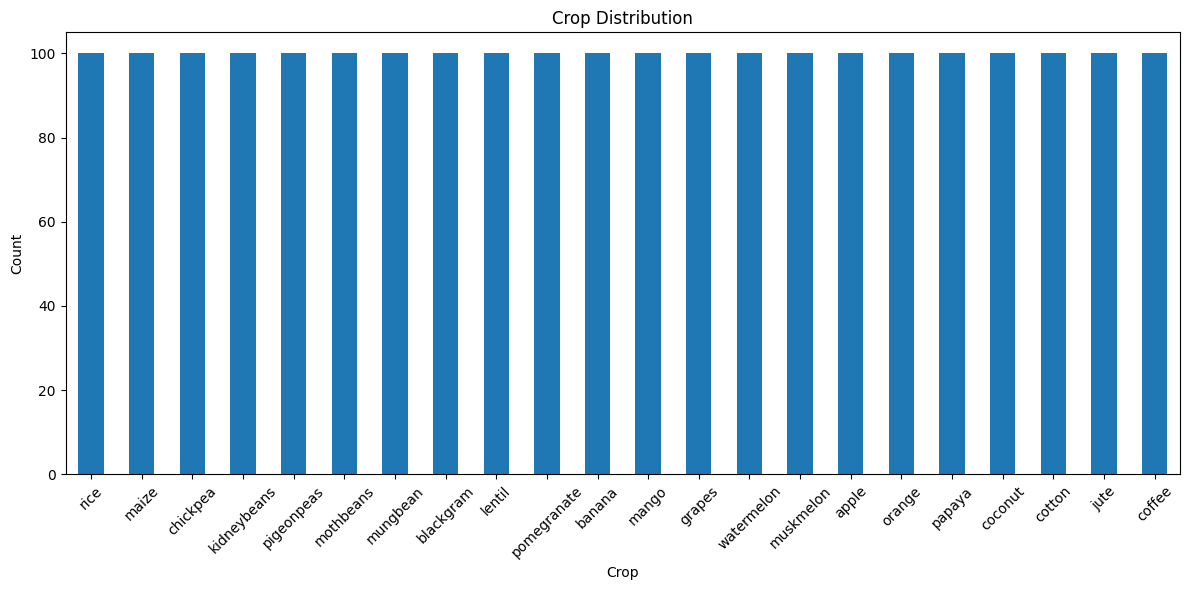

In [5]:
# --------------------------------------------------
# Crop Distribution
# --------------------------------------------------

plt.figure(figsize=(12, 6))
crop['label'].value_counts().plot(kind='bar')
plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/crop_distribution.png")
plt.show()

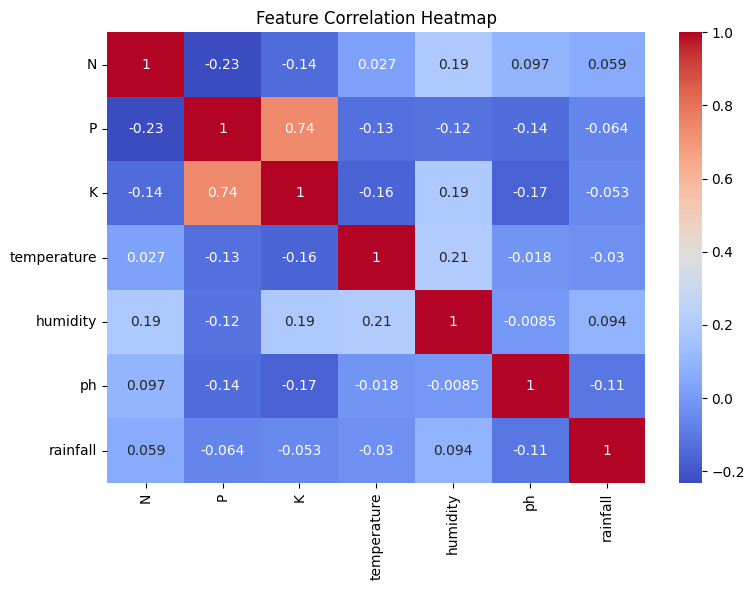

In [6]:
# --------------------------------------------------
# Correlation Heatmap
# --------------------------------------------------

plt.figure(figsize=(8, 6))
sns.heatmap(
    crop.drop("label", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("screenshots/correlation_heatmap.png")
plt.show()


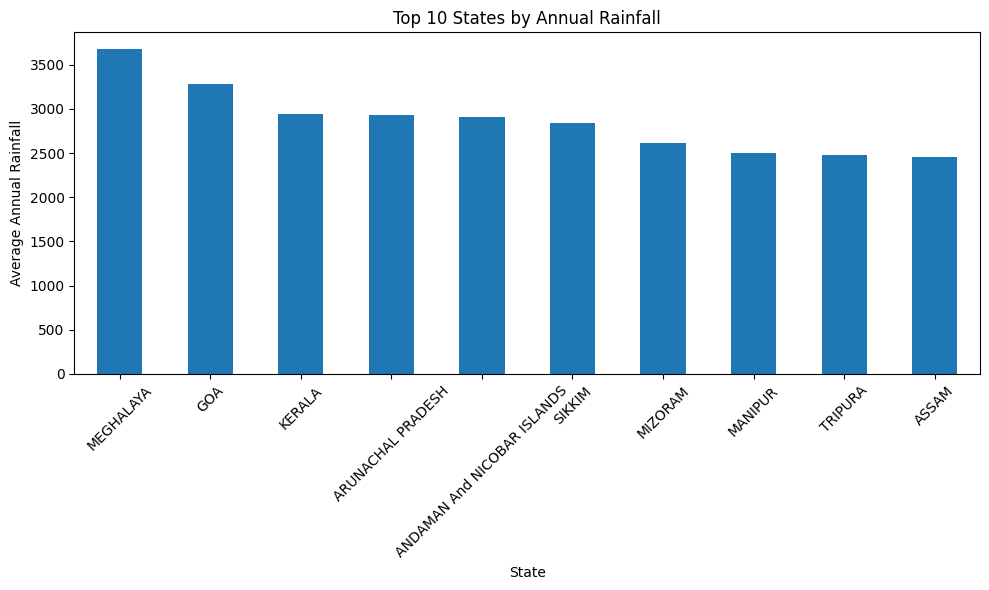

In [7]:
# --------------------------------------------------
# Top 10 States by Rainfall
# --------------------------------------------------

state_rainfall = (
    rainfall.groupby("STATE_UT_NAME")["ANNUAL"]
    .mean()
    .sort_values(ascending=False)
)

top10_states = state_rainfall.head(10)

plt.figure(figsize=(10, 6))
top10_states.plot(kind="bar")
plt.title("Top 10 States by Annual Rainfall")
plt.xlabel("State")
plt.ylabel("Average Annual Rainfall")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/top_rainfall_states.png")
plt.show()

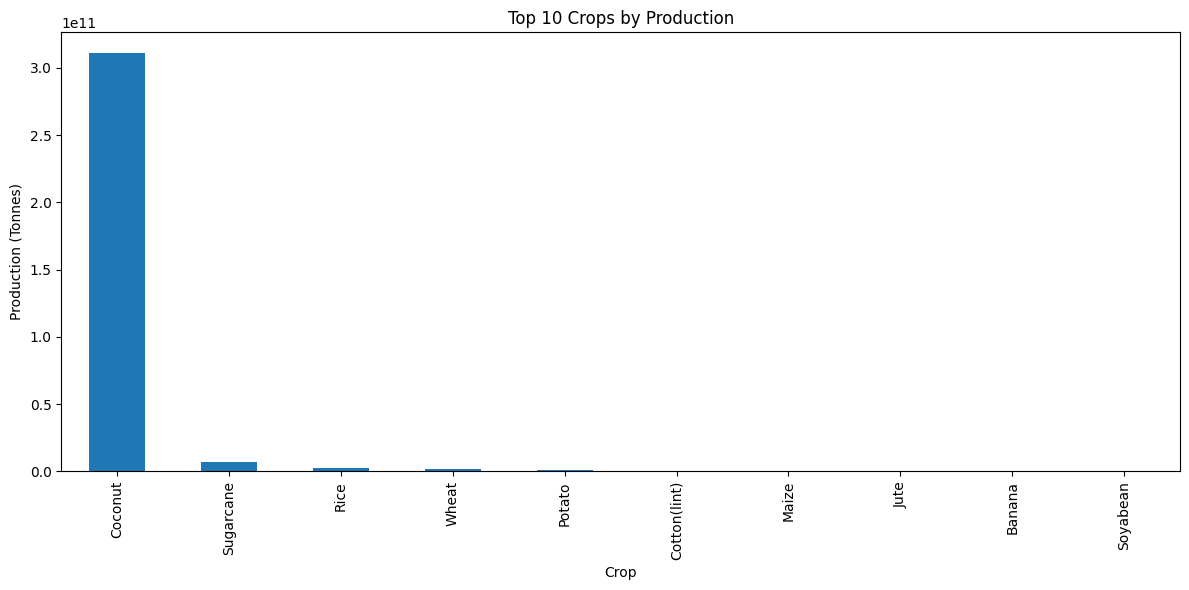

In [8]:
# Top 10 crops by total production

top_crops = (
    production.groupby("Crop")["Production"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_crops.plot(kind="bar")

plt.title("Top 10 Crops by Production")
plt.xlabel("Crop")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()

plt.savefig("screenshots/top_crops_production.png")

plt.show()

In [9]:
# --------------------------------------------------
# Crop Dataset Statistics
# --------------------------------------------------

print("\n" + "=" * 50)
print("CROP DATASET STATISTICS")
print("=" * 50)

print(crop.describe())

crop.describe().to_csv("screenshots/crop_statistics.csv")

print("\nEDA Completed Successfully!")
print("\nGenerated Files:")

for file in os.listdir("screenshots"):
    print("✓", file)


CROP DATASET STATISTICS
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.000000    22.769375    60.261953   
50%      37.000000    51.000000    32.000000    25.598693    80.473146   
75%      84.250000    68.000000    49.000000    28.561654    89.948771   
max     140.000000   145.000000   205.000000    43.675493    99.981876   

                ph     rainfall  
count  2200.000000  2200.000000  
mean      6.469480   103.463655  
std       0.773938    54.958389  
min       3.504752    20.211267  
25%       5.971693    64.551686  
50%       6.425045    94.867624  
75%       6.923643   124.267508  
max       9.935091   298.560117  

E

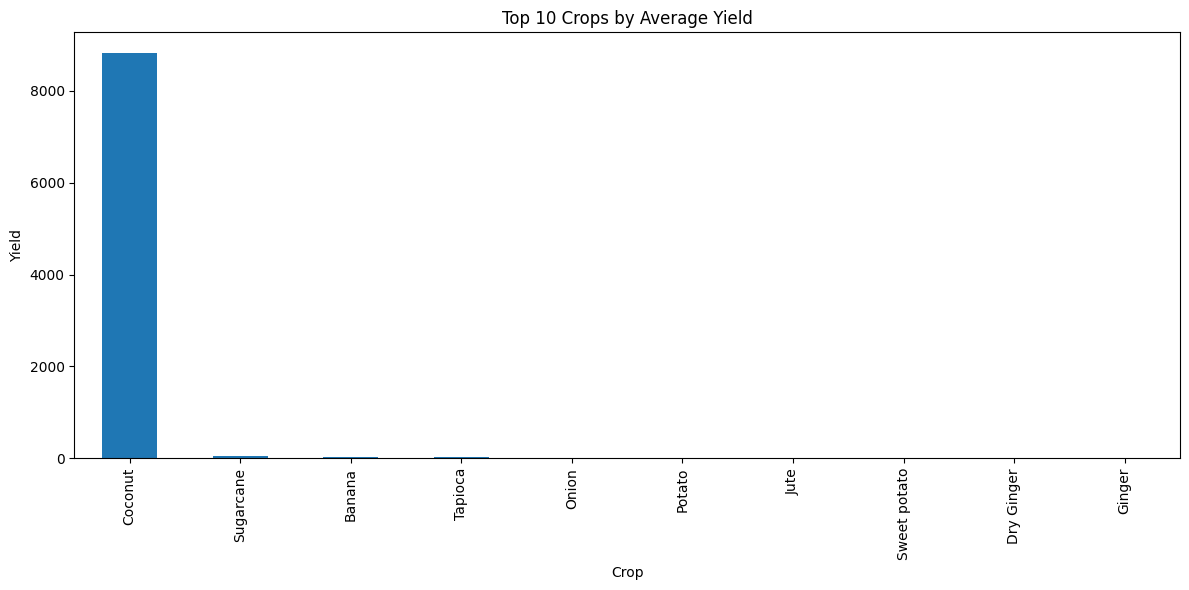

In [10]:
top_yield = (
    production.groupby("Crop")["Yield"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

top_yield.plot(kind="bar")

plt.title("Top 10 Crops by Average Yield")
plt.xlabel("Crop")
plt.ylabel("Yield")

plt.tight_layout()

plt.savefig("screenshots/top_crop_yield.png")

plt.show()

In [11]:
print(crop.shape)
print(rainfall.shape)
print(production.shape)

(2200, 8)
(641, 19)
(345407, 10)


In [12]:
crop.isnull().sum()
rainfall.isnull().sum()
production.isnull().sum()

State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64

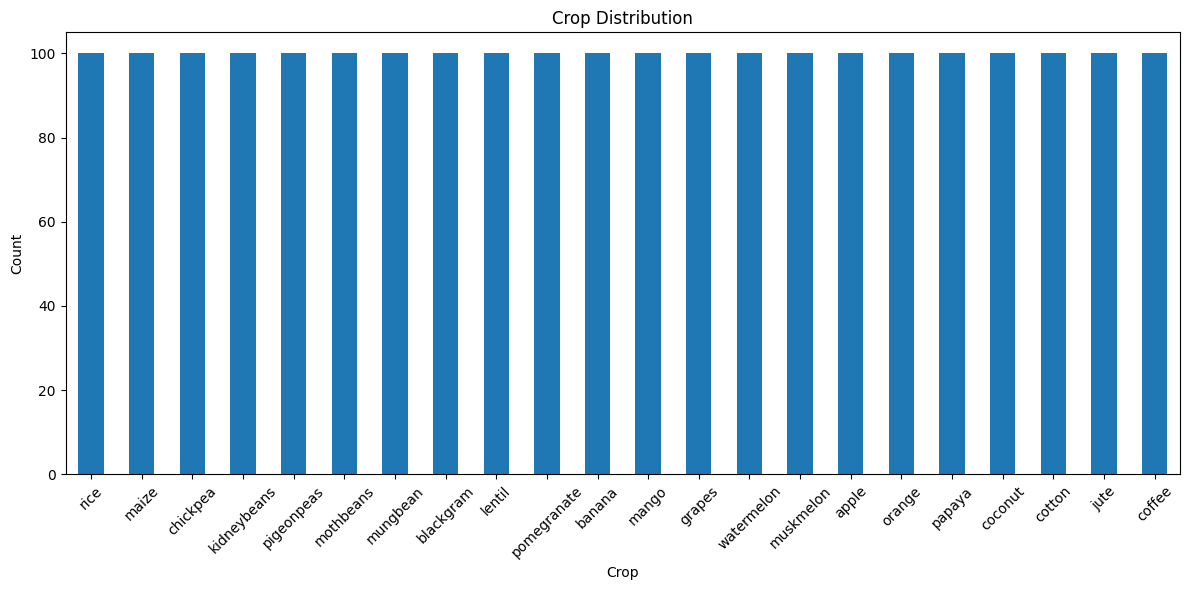

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

crop['label'].value_counts().plot(kind='bar')

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("screenshots/crop_distribution.png")

plt.show()

In [14]:
print("Crop Dataset Missing Values")
print(crop.isnull().sum())

print("\nRainfall Dataset Missing Values")
print(rainfall.isnull().sum())

print("\nProduction Dataset Missing Values")
print(production.isnull().sum())

Crop Dataset Missing Values
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Rainfall Dataset Missing Values
STATE_UT_NAME    0
DISTRICT         0
JAN              0
FEB              0
MAR              0
APR              0
MAY              0
JUN              0
JUL              0
AUG              0
SEP              0
OCT              0
NOV              0
DEC              0
ANNUAL           0
Jan-Feb          0
Mar-May          0
Jun-Sep          0
Oct-Dec          0
dtype: int64

Production Dataset Missing Values
State                  0
District               0
Crop                  32
Year                   0
Season                 1
Area                  33
Area Units             0
Production          4993
Production Units       0
Yield                 33
dtype: int64


In [15]:
print("Crop Dataset Shape:")
print(crop.shape)

print("\nRainfall Dataset Shape:")
print(rainfall.shape)

print("\nProduction Dataset Shape:")
print(production.shape)

print("\nCrop Dataset Columns:")
print(list(crop.columns))

print("\nRainfall Dataset Columns:")
print(list(rainfall.columns))

print("\nProduction Dataset Columns:")
print(list(production.columns))

Crop Dataset Shape:
(2200, 8)

Rainfall Dataset Shape:
(641, 19)

Production Dataset Shape:
(345407, 10)

Crop Dataset Columns:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

Rainfall Dataset Columns:
['STATE_UT_NAME', 'DISTRICT', 'JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN', 'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec']

Production Dataset Columns:
['State', 'District', 'Crop', 'Year', 'Season', 'Area', 'Area Units', 'Production', 'Production Units', 'Yield']
